C:\Users\minkyu\AppData\Local\Temp\ipykernel_36000\652143946.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load('savepoints/autoenco

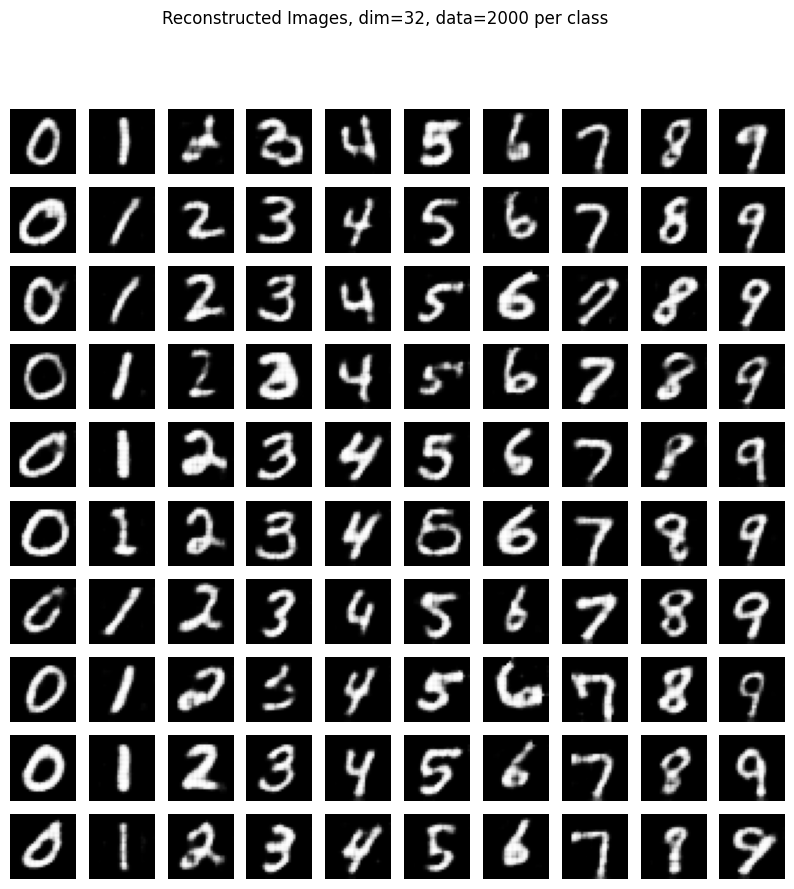

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import Variable
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import importlib
from tqdm import tqdm

from modules import Autoencoder
importlib.reload(Autoencoder)  # 모듈 갱신

# 오토인코더 모델 로드
latent_dim = 32
autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
autoencoder.load_state_dict(torch.load('savepoints/autoencoder.pth'))
autoencoder.eval()  # 평가 모드로 전환

num_images_per_class = 2000

# 데이터 로드
data = np.load(f'./data/MNIST/mnist_{num_images_per_class}.npz')

# 클래스별로 10개의 latent 벡터를 선택하고 복원
reconstructed_images = []
for digit in tqdm(range(10)):
    latent_data = data[f'{digit}_latent']  # 각 클래스의 latent 벡터 불러오기
    # 10개의 latent 벡터를 텐서로 변환
    latent_vectors = torch.tensor(latent_data[:10], dtype=torch.float32)
    
    # 오토인코더의 디코더로 복원
    with torch.no_grad():
        reconstructed = autoencoder.decoder(latent_vectors)  # (10, 1, 28, 28)
    reconstructed_images.append(reconstructed)

# 10x10 그리드에 시각화
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for i in range(10):
    for j in range(10):
        # (1, 28, 28) 형태를 (28, 28)으로 변환하여 시각화
        axs[j, i].imshow(reconstructed_images[i][j].squeeze().detach().numpy(), cmap='gray')
        axs[j, i].axis('off')

plt.suptitle(f"Reconstructed Images, dim={latent_dim}, data={num_images_per_class} per class")
plt.show()

# Choose one class to train

In [9]:
# Standard Libraries
import math
import pickle
import random

# Data Manipulation and Visualization
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

# Quantum Computing
import pennylane as qml

DIGIT = 0 # 0을 생성하도록 학습한다
print("이번 학습으로 생성할 숫자는", DIGIT, "입니다.")

# 학습 데이터, 테스트 데이터, 검증 데이터를 2:1:1로 나눈다.
train_dataset = data[f'{DIGIT}_latent'][:num_images_per_class//2]
test_dataset = data[f'{DIGIT}_latent'][num_images_per_class//2:num_images_per_class*3//4]
val_dataset = data[f'{DIGIT}_latent'][num_images_per_class*3//4:]
train_size, test_size, val_size = len(train_dataset), len(test_dataset), len(val_dataset)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("학습에 사용할 device =",device)

n_qubits = 5
code_qubits = 1
noise_qubits = n_qubits - code_qubits
output_qubits = 5 # 출력 차원은 2**output_qubits 만큼.
assert(code_qubits <= n_qubits)

n_layers = 10
BATCH_SIZE = 16
print("n_qubits = {} n_layers = {} 총 파라미터 수 = {}".format(n_qubits, n_layers, n_qubits*n_layers*3))

dev = qml.device("default.qubit", wires=n_qubits)

이번 학습으로 생성할 숫자는 0 입니다.
학습에 사용할 device = cpu
n_qubits = 5 n_layers = 10 총 파라미터 수 = 150


In [10]:
import importlib
import matplotlib.pyplot as plt
from modules import QGAN, Discriminator, MINE  # 초기 import
importlib.reload(QGAN)  # 모듈 갱신
importlib.reload(Discriminator)  # 모듈 갱신
importlib.reload(MINE)  # 모듈 갱신

# 생성자 파라미터 초기화 및 모듈 불러오기
generator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi/2 , np.pi/2, (n_layers, n_qubits, 3))), requires_grad=True)
generator = QGAN.QGAN(n_qubits, output_qubits, n_layers, generator_initial_params, dev)

# 판별자, MINE 초기화
discriminator = Discriminator.LinearDiscriminator(input_dim = 2**output_qubits)
mine = MINE.LinearMine(code_qubits=code_qubits, output_dim=2**output_qubits)

In [11]:
G_lr = 0.001
D_lr = 0.0003
M_lr = 0.001
coeff = 0.1

use_mine = False
train_type = "InfoQGAN" if use_mine else "QGAN"
G_opt = torch.optim.Adam([generator.params], lr=G_lr)
D_opt = torch.optim.Adam(discriminator.parameters(), lr=D_lr)
M_opt = torch.optim.Adam(mine.parameters(), lr=M_lr)

학습에 사용할 train_step과 disc_cost_fn 정의 

In [12]:
def generator_train_step(generator_input, use_mine = False):
    '''
    params (torch.Tensor(레이어,큐빗,3)): a parameter
    generator_input (torch.Tensor(BATCH_SIZE, n_qubits)): 생성기 입력 seed (noise + code). -1~1 사이의 값
    '''
    code_input = generator_input[:, -code_qubits:] # 입력중에서 code만 뽑는다. (BATCH_SIZE, code_qubits)

    generator_output = generator.forward(generator_input) # 출력을 뽑아낸다 (BATCH_SIZE, 2**output_qubits)

    generator_output = generator_output.to(torch.float32) # (BATCH_SIZE, output_qubits)
    
    disc_output = discriminator(generator_output) # 밑에 코드에서 정의됨
    gan_loss = torch.log(1-disc_output).mean()
    
    if use_mine:
        pred_xy = mine(code_input, generator_output)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, generator_output)
        mi = torch.mean(pred_xy) - torch.log(torch.mean(torch.exp(pred_x_y)))
        gan_loss -= coeff * mi

    return generator_output, gan_loss# TODO: 이건 분석용으로 넣어놓음.지워야 함.

disc_loss_fn = nn.BCELoss()
def disc_cost_fn(real_input, fake_input, smoothing=False):
    batch_num = real_input.shape[0]

    disc_real = discriminator(real_input)
    disc_fake = discriminator(fake_input)

    real_label = torch.ones((batch_num, 1)).to(device)
    fake_label = torch.zeros((batch_num, 1)).to(device)
    
    if smoothing:
        real_label = real_label - 0.2*torch.rand(real_label.shape).to(device)
    
    loss = 0.5 * (disc_loss_fn(disc_real, real_label) + disc_loss_fn(disc_fake, fake_label))
    
    return loss

In [13]:
import torch
import matplotlib.pyplot as plt

def visualize_output_simple(gen_outputs, gen_codes, epoch, writer, image_file_path):
    # gen_outputs를 decoder에 통과시켜 이미지로 변환
    latent_vectors = torch.tensor(gen_outputs[:100], dtype=torch.float32)
    
    # 오토인코더의 디코더로 복원
    with torch.no_grad():
        reconstructed = autoencoder.decoder(latent_vectors)  # (100, 1, 28, 28)
    
    # 1. 첫 번째 플롯: 10*10 그리드에 reconstructed 이미지 시각화 (랜덤 순서)
    fig, axs = plt.subplots(10, 10, figsize=(10, 10))
    for i in range(10):
        for j in range(10):
            axs[j, i].imshow(reconstructed[i*10+j].squeeze().detach().numpy(), cmap='gray')
            axs[j, i].axis('off')
    plt.suptitle(f"DIGIT={DIGIT} epoch={epoch} dim={latent_dim}")
    writer.add_figure(f'2D Distribution', fig, epoch)
    fig.savefig(f'{image_file_path}/epoch{epoch:03d}_generated.png')
    plt.close(fig)

    # 2. code_qubits 값별로 정렬하여 10*10 이미지 배치 생성 및 저장
    code_qubits = gen_codes.shape[1]
    front_100_codes = gen_codes[:100]  # gen_codes에서 앞 100개의 코드만 사용
    for q in range(code_qubits):
        # 각 code_qubit 값으로 정렬
        sorted_indices = front_100_codes[:, q].argsort()
        sorted_reconstructed = reconstructed[sorted_indices]  # 정렬된 상위 100개 사용

        fig, axs = plt.subplots(10, 10, figsize=(10, 10))
        for i in range(10):
            for j in range(10):
                axs[j, i].imshow(sorted_reconstructed[i*10+j].squeeze().detach().numpy(), cmap='gray')
                axs[j, i].axis('off')
        plt.suptitle(f"DIGIT={DIGIT} epoch={epoch} dim={latent_dim} code_qubit={q}")
        
        # TensorBoard에 기록
        writer.add_figure(f'Sorted by Code Qubit {q}', fig, epoch)
        fig.savefig(f'{image_file_path}/epoch{epoch:03d}_sorted_{q}.png')
        plt.close(fig)


실제 학습 진행

In [14]:
from scipy.linalg import sqrtm

def calculate_frechet_distance(gen_outputs, val_dataset):
    # gen_outputs: (_, 2**output_qubits), val_dataset: (_, 2**output_qubits)
    # 평균과 공분산 계산
    mu1, sigma1 = gen_outputs.mean(axis=0), np.cov(gen_outputs, rowvar=False)
    mu2, sigma2 = val_dataset.mean(axis=0), np.cov(val_dataset, rowvar=False)

    # Frechet Distance 계산
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):  # 실수 부분만 사용
        covmean = covmean.real

    frechet_distance = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return frechet_distance

In [ ]:
from torch.utils.tensorboard import SummaryWriter
import ndtest # 2D 분포 검정에 사용
from datetime import datetime
import os
import time
from modules.utils import convert_ipynb_to_html # 현재 html파일 저장을 위해 사용

current_time = datetime.now().strftime("%b%d_%H_%M_%S")  # "Aug13_14_12_30" 형식
save_dir = f"./runs/MNIST{DIGIT}_{train_type}_{current_time}"
scalar_save_path = os.path.join(save_dir, f"MNIST{DIGIT}_{train_type}_{current_time}.csv")
image_save_dir = os.path.join(save_dir, "images")
param_save_dir = os.path.join(save_dir, "params")
os.makedirs(image_save_dir, exist_ok=True)
os.makedirs(param_save_dir, exist_ok=True)

convert_ipynb_to_html('mnist_train.ipynb', os.path.join(save_dir, "mnist_train.html"))

# CSV 파일 초기화 (헤더 작성)
df = pd.DataFrame(columns=['epoch', 'D_loss', 'G_loss', 'MI', 'FD', 'time'])

# TensorBoard SummaryWriter 초기화
writer = SummaryWriter(log_dir=save_dir)

epoch_num = 300
start_time = time.time()

for epoch in range(1, epoch_num+1):
    G_loss_sum = 0.0
    D_loss_sum = 0.0
    mi_sum = 0.0
    batch_num = train_size // BATCH_SIZE
    pbar = tqdm(range(batch_num))

    # 그림 그릴때 필요하다
    gen_outputs = [] # (데이터수, 2) 생성한 모든 점의 좌표들
    gen_codes = [] # (데이터수, 2) 점 찍는데 들어간 code들
    train_dataset = train_dataset[np.random.permutation(train_dataset.shape[0])] # 매 epoch마다 데이터를 섞는다.
    for batch_idx in pbar:
        batch = torch.FloatTensor(train_dataset[BATCH_SIZE * batch_idx : BATCH_SIZE * batch_idx + BATCH_SIZE])

        # train generator
        generator_seed = torch.rand((BATCH_SIZE, n_qubits))*2-1
        generator_output, generator_loss = generator_train_step(generator_seed, use_mine=use_mine)
        G_opt.zero_grad()
        generator_loss.requires_grad_(True)
        generator_loss.backward()
        G_opt.step()
        
        # train discriminator
        fake_input = generator_output.detach().to(torch.float32)
        disc_loss = disc_cost_fn(batch, fake_input, smoothing=False)
        D_opt.zero_grad()
        disc_loss.requires_grad_(True)
        disc_loss.backward()
        D_opt.step()

        # train mine
        code_input = generator_seed[:, -code_qubits:] # (BATCH_SIZE, code_qubits) 코드만 추출
        pred_xy = mine(code_input, fake_input)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, fake_input)
        mi = -torch.mean(pred_xy) + torch.log(torch.mean(torch.exp(pred_x_y)))
        M_opt.zero_grad()
        mi.requires_grad_(True)
        mi.backward()
        M_opt.step()

        D_loss_sum += disc_loss.item()
        G_loss_sum += generator_loss.item()
        mi_sum -= mi.item() # (-1)곱해져 있어서 빼야함.

        gen_outputs.append(fake_input.numpy())
        gen_codes.append(code_input.numpy())

        pbar.set_postfix({'G_loss': G_loss_sum/(batch_idx+1), 'D_loss': D_loss_sum/(batch_idx+1), 'MI': mi_sum/(batch_idx+1)})

    # G_scheduler.step()
    # D_scheduler.step()
    # M_scheduler.step()
    
    gen_outputs = np.concatenate(gen_outputs, axis=0) # (train_num, 2**output_qubits)
    gen_codes = np.concatenate(gen_codes, axis=0) # (train_num, code_qubits)

    D_loss, G_loss, mi = D_loss_sum/batch_num, G_loss_sum/batch_num, mi_sum/batch_num

    # calculate FD between generated data and val data
    frechet_distance = calculate_frechet_distance(gen_outputs, val_dataset)
    

    writer.add_scalar('Loss/d_loss', D_loss, epoch)
    writer.add_scalar('Loss/g_loss', G_loss, epoch)
    writer.add_scalar('Metrics/mi', mi, epoch)
    writer.add_scalar('Metrics/FD', frechet_distance, epoch)

    # 스칼라 값 CSV로 덮어쓰기 저장
    file_exists = os.path.isfile(scalar_save_path)
    new_data = pd.DataFrame({
        'epoch': [epoch],
        'D_loss': [D_loss],
        'G_loss': [G_loss],
        'MI': [mi],
        'FD': [frechet_distance],
        'time': [int((time.time() - start_time)*1000)]
    })

    new_data.to_csv(scalar_save_path, mode='a', header=not file_exists)
    
    visualize_output_simple(gen_outputs, gen_codes, epoch, writer, image_save_dir) # save fig here

    # 각 epoch마다 generator 파라미터 저장
    torch.save(generator.params, f'{param_save_dir}/generator_params_epoch{epoch}.pth')
    
    print("epoch: {}, D_loss: {}, G_loss: {}, MI = {}, FD = {}".format(epoch, D_loss, G_loss, mi, frechet_distance))

HTML 파일이 ./runs/MNIST0_QGAN_Nov01_15_17_45\mnist_train.html에 저장되었습니다.


 42%|████▏     | 26/62 [00:41<00:57,  1.59s/it, G_loss=-.712, D_loss=0.687, MI=-.0028] 

In [ ]:
dsf